In [108]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
warnings.filterwarnings("ignore")

In [109]:
df = pd.read_csv(r'E:\\AV_Capstone_Project\\Data\\test\\train_F3WbcTw_1icmK82.csv')

In [110]:
df.head()

,unique_hash,text,drug,sentiment
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,Autoimmune diseases tend to come in clusters. ...,gilenya,2
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,I can completely understand why you’d want to ...,gilenya,2
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 recep...,fingolimod,2
3,bd22104dfa9ec80db4099523e03fae7a52735eb6,"Very interesting, grand merci. Now I wonder wh...",ocrevus,2
4,b227688381f9b25e5b65109dd00f7f895e838249,"Hi everybody, My latest MRI results for Brain ...",gilenya,1


In [111]:
print(df.shape)

(5279, 4)


In [112]:
df.columns.tolist()

['unique_hash', 'text', 'drug', 'sentiment']

In [113]:
df.duplicated().sum()

np.int64(0)

In [114]:
df['sentiment'].value_counts()

sentiment
2    3825
1     837
0     617
Name: count, dtype: int64

<Axes: xlabel='sentiment'>

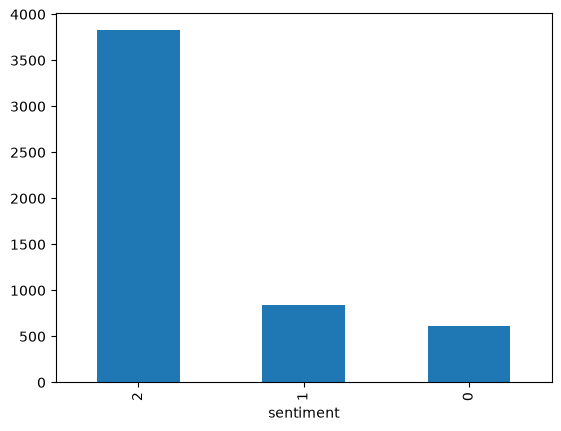

In [115]:
df['sentiment'].value_counts().plot(kind='bar')

<Axes: xlabel='drug'>

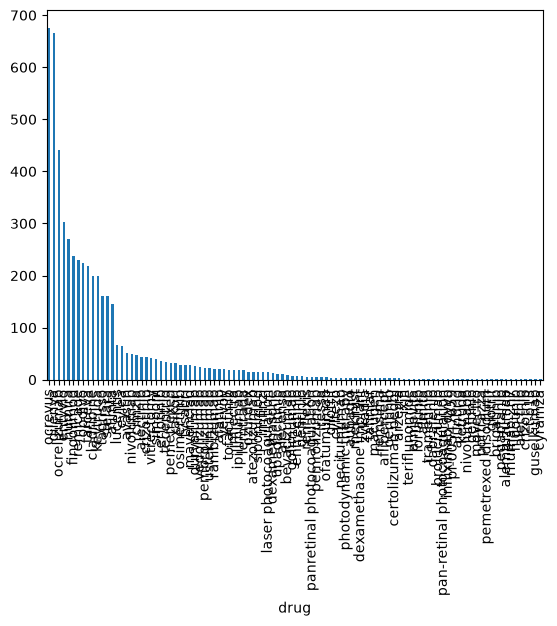

In [116]:
df['drug'].value_counts().plot(kind='bar')

In [117]:
len(df['drug'].value_counts())

102

In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5279 entries, 0 to 5278
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   unique_hash  5279 non-null   str  
 1   text         5279 non-null   str  
 2   drug         5279 non-null   str  
 3   sentiment    5279 non-null   int64
dtypes: int64(1), str(3)
memory usage: 165.1 KB


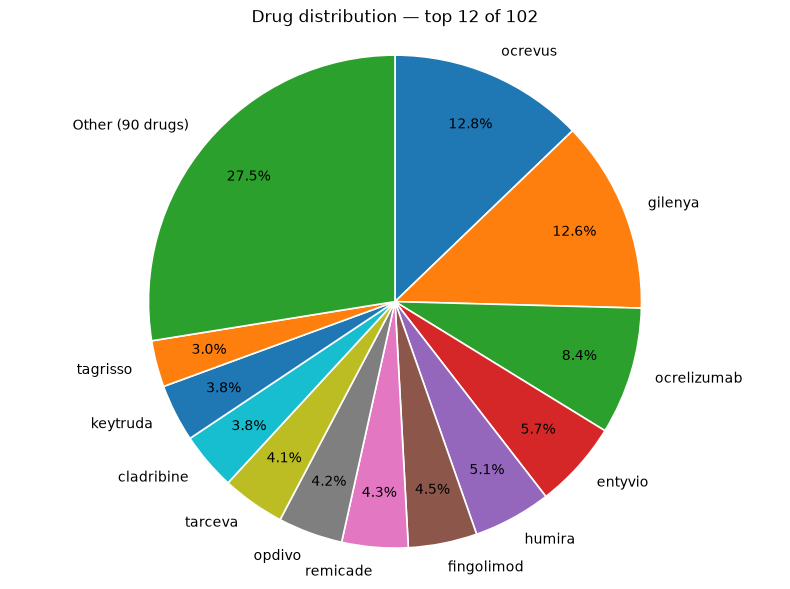

In [119]:
import matplotlib.pyplot as plt

TOP_N = 12

counts = df['drug'].value_counts()
top    = counts.head(TOP_N)
other  = counts.iloc[TOP_N:].sum()

labels = list(top.index) + [f'Other ({len(counts) - TOP_N} drugs)']
values = list(top.values) + [other]

plt.figure(figsize=(8, 6))
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
)
plt.title(f'Drug distribution — top {TOP_N} of {len(counts)}')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [120]:
df.describe(include='all')

,unique_hash,text,drug,sentiment
count,5279,5279,5279,5279.000000
unique,5279,5181,102,NaN
top,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,The Center for Biosimilars ® recaps the top ne...,ocrevus,NaN
freq,1,3,676,NaN
mean,NaN,NaN,NaN,1.607691
std,NaN,NaN,NaN,0.687203
min,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,1.000000
50%,NaN,NaN,NaN,2.000000
75%,NaN,NaN,NaN,2.000000


In [121]:
df.isnull().sum()

unique_hash    0
text           0
drug           0
sentiment      0
dtype: int64

In [122]:
label_names = {
    0: "positive",
    1: "negative",
    2: "neutral"
}

class_counts = df["sentiment"].value_counts().sort_index()

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": class_counts / len(df) * 100
})

class_distribution["label"] = class_distribution.index.map(label_names)

class_distribution

,count,percentage,label
sentiment,,,
0,617,11.687820,positive
1,837,15.855276,negative
2,3825,72.456905,neutral


In [123]:
max_count = class_counts.max()
min_count = class_counts.min()

imbalance_ratio = max_count / min_count

print("Imbalance ratio:", round(imbalance_ratio, 2))

# 1.0 → perfectly balanced
# 2.0 → largest class is 2x smallest
# 5.0 → significant imbalance
# 10+ → severe imbalance

# 5.0 → significant imbalance (now it is 6+ so it is balanced)

Imbalance ratio: 6.2


In [124]:
# it lets me manually look at examples from positive, negative, and neutral classes to understand whether the labels actually make sense.

for label in sorted(df["sentiment"].unique()):
    print("=" * 80)
    print(f"LABEL {label} → {label_names[label]}")
    print("=" * 80)

    samples = df[df["sentiment"] == label]["text"].sample(
        min(5, (df["sentiment"] == label).sum()),
        random_state=42
    )

    for text in samples:
        print("-", text[:500])
        print()

LABEL 0 → positive
-  Opdivo - in my case - has been a miracle drug. Thought I'd post this shout-out for those who'd seen my previos posts.

- Hi Bfarz! Glad to hear the Tagrisso is working.  Hope you continue to have great response and control from it! Just a note on 4th generation TKIs.  There actually is an ongoing trial of a new TKI designed to treat the most common resistant mutations ( i.e. Exon 20 mutations) from EGFR as well as the Exon 20 mutation of HER2.  It even has a test cohort of patients with more typical Exon 19/21 mutations.  It is clinical trial of a drug AP32788 (originally from Ariad Pharmaceuticals, bought out by 

- I JUST took only one (my BF is sitting with me now cuz I' have high anxiety starting something new)and see if I feel okay in a few hours, if okay after dinner I will take two. UC since '05, now in '15 Mayo Clinic say Chrons/colitis and DX with chronic Lyme's in '10. No biologics work. Now on Stelara and love it!!Took rafaximin for SIBO, worked awesome

In [125]:
positive_words = [
    "great", "love", "amazing", "wonderful",
    "thankful", "grateful", "improved",
    "improvement", "helping", "helped",
    "works well", "remission",
    "stable", "hope", "better"
]

negative_words = [
    "awful", "terrible", "horrible",
    "worst", "hate", "failed",
    "stopped working", "side effects",
    "pain", "nausea", "fatigue",
    "worse", "scared", "frustrated",
    "relapse", "progression"
]

In [126]:
low_text = df["text"].str.lower()

df["positive_hits"] = sum(
    low_text.str.count(word)
    for word in positive_words
)

df["negative_hits"] = sum(
    low_text.str.count(word)
    for word in negative_words
)

In [127]:
df.groupby("sentiment")[[
    "positive_hits",
    "negative_hits"
]].mean()

,positive_hits,negative_hits
sentiment,,
0,1.606159,1.573744
1,1.236559,2.057348
2,1.291765,1.763399


In [128]:
df["word_count"] = df["text"].str.split().str.len()
df["char_count"] = df["text"].str.len()

In [129]:
df[["word_count", "char_count"]].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)


,word_count,char_count
count,5279.000000,5279.000000
mean,341.401781,2075.701080
std,795.163645,5075.540253
min,1.000000,6.000000
5%,25.000000,146.000000
25%,72.500000,419.000000
50%,141.000000,807.000000
75%,292.000000,1706.000000
90%,670.600000,4191.600000
95%,1316.000000,8327.500000


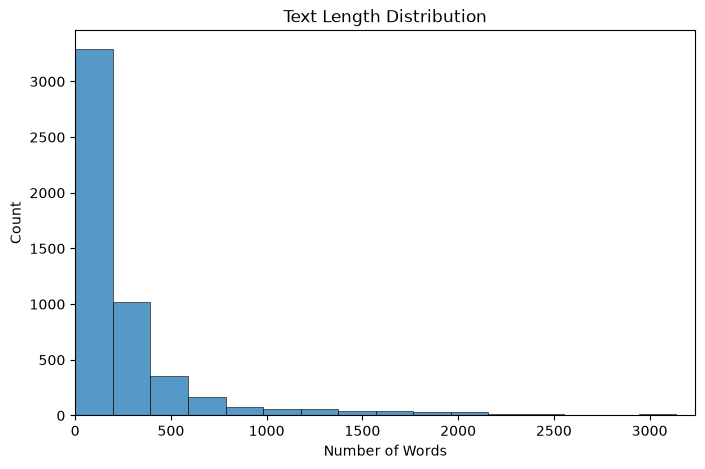

In [130]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["word_count"],
    bins=100
)

plt.xlim(0, df["word_count"].quantile(0.99))

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")

plt.show()

In [131]:
duplicate_count = df["text"].duplicated().sum()

print("duplicates rows:", duplicate_count)

#only text 

duplicates rows: 98


In [132]:
duplicate_groups = (
    df[df["text"].duplicated(keep=False)]
    .groupby("text")
)

In [133]:
multi_drug = 0

for text, group in duplicate_groups:
    if group["drug"].nunique() > 1:
        multi_drug += 1

print("Duplicate groups with multiple drugs:", multi_drug)

Duplicate groups with multiple drugs: 88


In [134]:
duplicates = df[df.duplicated(keep=False)]

print(duplicates)

Empty DataFrame
Columns: [unique_hash, text, drug, sentiment, positive_hits, negative_hits, word_count, char_count]
Index: []


In [135]:
df.head()

,unique_hash,text,drug,sentiment,positive_hits,negative_hits,word_count,char_count
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,Autoimmune diseases tend to come in clusters. ...,gilenya,2,1,0,76,404
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,I can completely understand why you’d want to ...,gilenya,2,2,0,206,1184
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 recep...,fingolimod,2,0,0,134,780
3,bd22104dfa9ec80db4099523e03fae7a52735eb6,"Very interesting, grand merci. Now I wonder wh...",ocrevus,2,0,0,20,124
4,b227688381f9b25e5b65109dd00f7f895e838249,"Hi everybody, My latest MRI results for Brain ...",gilenya,1,0,1,115,612


In [136]:
def count_drug_mentions(row):
    return row["text"].lower().count(row["drug"].lower())

In [137]:
df["drug_mentions"] = df.apply(
    count_drug_mentions,
    axis=1
)

In [138]:
print(
    "Rows where drug is never mentioned:",
    (df["drug_mentions"] == 0).sum()
)

Rows where drug is never mentioned: 11


In [139]:
print(
    "Percentage:",
    (df["drug_mentions"] == 0).mean() * 100
)

Percentage: 0.20837279787838606


In [140]:
df['drug_mentions'].value_counts()

drug_mentions
1      3476
2       946
3       354
4       188
5        94
6        61
7        35
8        24
9        18
0        11
11       10
10       10
13        9
20        5
16        4
14        3
15        3
19        3
31        2
27        2
18        2
12        2
102       1
86        1
21        1
66        1
22        1
62        1
24        1
26        1
32        1
17        1
41        1
30        1
65        1
84        1
28        1
57        1
61        1
Name: count, dtype: int64

In [141]:
drug_counts = df["drug"].value_counts()

print("Unique drugs:", drug_counts.nunique())

Unique drugs: 46


In [142]:
print("Number of unique drugs:", drug_counts.shape[0])

Number of unique drugs: 102


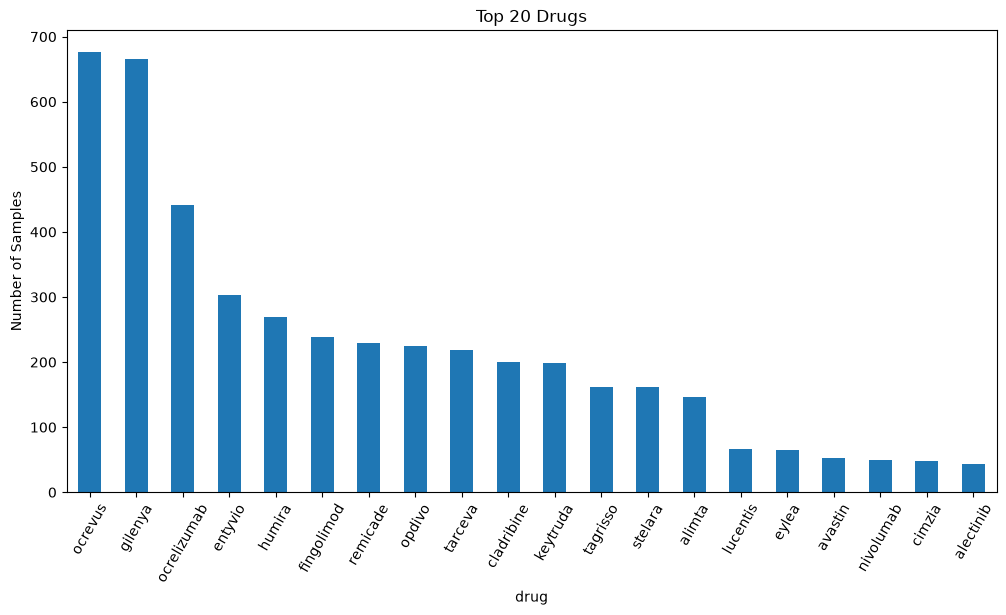

In [143]:
plt.figure(figsize=(12, 6))

drug_counts.head(20).plot(kind="bar")

plt.title("Top 20 Drugs")
plt.ylabel("Number of Samples")

plt.xticks(rotation=60)

plt.show()

In [144]:
print(
    "Drugs with fewer than 10 samples:",
    (drug_counts < 10).sum()
)

Drugs with fewer than 10 samples: 53


In [145]:
print(
    "Drugs with exactly 1 sample:",
    (drug_counts == 1).sum()
)

Drugs with exactly 1 sample: 21


In [146]:
drug_sentiment = pd.crosstab(
    df["drug"],
    df["sentiment"]
)

drug_sentiment.head()

sentiment,0,1,2
drug,,,
afatinib,2,2,16
aflibercept,0,0,3
alecensa,3,0,7
alectinib,11,3,29
alectnib,0,0,1


In [147]:
drug_sentiment_pct = pd.crosstab(
    df["drug"],
    df["sentiment"],
    normalize="index"
) * 100

drug_sentiment_pct.head(20)

sentiment,0,1,2
drug,,,
afatinib,10.000000,10.000000,80.000000
aflibercept,0.000000,0.000000,100.000000
alecensa,30.000000,0.000000,70.000000
alectinib,25.581395,6.976744,67.441860
alectnib,0.000000,0.000000,100.000000
alemtuzumab,0.000000,0.000000,100.000000
alimta,7.534247,13.013699,79.452055
almita,50.000000,0.000000,50.000000
alunbrig,0.000000,100.000000,0.000000


In [148]:
df["has_url"] = df["text"].str.contains(
    r"https?://|www\.",
    regex=True
)

print(df["has_url"].mean())

0.11612047736313696


In [149]:
df["has_html"] = df["text"].str.contains(
    r"<[a-z/][^>]*>",
    regex=True
)

print(df["has_html"].mean())

0.0011365788975184693


In [150]:
df["has_non_ascii"] = df["text"].str.contains(
    r"[^\x00-\x7F]",
    regex=True
)

print(df["has_non_ascii"].mean())

0.45027467323356696


In [151]:
FIRST_PERSON = r"\b(i|my|me|mine|myself|i'm|im|i've|ive|i'd|i'll)\b"

CLINICAL_VOCAB = (
    r"\b(phase|trial|study|placebo|endpoint|efficacy|fda|approval|approved|"
    r"patients|cohort|randomi[sz]|double.blind|primary endpoint|statistically|"
    r"p\s?[<=]\s?0|confidence interval|hazard ratio|median pfs|overall survival)\b"
)

In [152]:
df["first_person_count"] = (
    df["text"].str.lower().str.count(FIRST_PERSON)
)

df["clinical_count"] = (
    df["text"].str.lower().str.count(CLINICAL_VOCAB)
)

In [153]:
df.groupby("sentiment")[[
    "first_person_count",
    "clinical_count"
]].mean()

,first_person_count,clinical_count
sentiment,,
0,7.632091,4.680713
1,11.694146,1.394265
2,8.523660,4.071373


In [154]:
def clean_text(text):
    text = str(text)

    # Normalize quotes
    text = re.sub(r"[\u2018\u2019\u02bc]", "'", text)
    text = re.sub(r"[\u201c\u201d]", '"', text)

    # Normalize dashes
    text = re.sub(r"[\u2013\u2014]", "-", text)

    # HTML entities
    text = re.sub(
        r"&(amp|nbsp|quot|lt|gt);",
        " ",
        text
    )

    # HTML tags
    text = re.sub(
        r"<[a-z/][^>]*>",
        " ",
        text
    )

    # URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " <URL> ",
        text
    )

    # Extra whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [155]:
sample = "<p>I’m taking Ocrevus&nbsp;and it’s working well!</p>   Visit https://example.com   &amp; read more — really helpful."

print("BEFORE:")
print(sample)

print("\nAFTER:")
print(clean_text(sample))

BEFORE:
<p>I’m taking Ocrevus&nbsp;and it’s working well!</p>   Visit https://example.com   &amp; read more — really helpful.

AFTER:
I'm taking Ocrevus and it's working well! Visit <URL> read more - really helpful.


In [156]:
longest_text = df.loc[df["word_count"].idxmax(), "text"]

len(longest_text)
print(longest_text)

SERIOUS INFECTIONS Patients treated with Remicade  ® are at increased risk for developing serious infections that may lead to hospitalization or death  [see Warnings and Precautions (5.1) and Adverse Reactions (6.1) ] . Most patients who developed these infections were taking concomitant immunosuppressants such as methotrexate or corticosteroids. Remicade should be discontinued if a patient develops a serious infection or sepsis. Reported infections include: Active tuberculosis, including reactivation of latent tuberculosis. Patients with tuberculosis have frequently presented with disseminated or extrapulmonary disease. Patients should be tested for latent tuberculosis before Remicade use and during therapy.  1,2 Treatment for latent infection should be initiated prior to Remicade use. Invasive fungal infections, including histoplasmosis, coccidioidomycosis, candidiasis, aspergillosis, blastomycosis, and pneumocystosis. Patients with histoplasmosis or other invasive fungal infections 

In [157]:
def aspect_window(text, drug, window=40):
    tokens = text.split()

    drug = drug.lower()

    positions = [
        i for i, token in enumerate(tokens)
        if drug in token.lower()
    ]

    if not positions:
        return " ".join(tokens[:200])

    selected = set()

    for pos in positions:
        start = max(0, pos - window)
        end = min(len(tokens), pos + window + 1)

        selected.update(range(start, end))

    return " ".join(
        tokens[i]
        for i in sorted(selected)
    )

In [158]:
row = df.iloc[3344]

print("Drug:", row["drug"])

print(
    aspect_window(
        row["text"],
        row["drug"],
        window=40
    )
)

Drug: gilenya
intramuscular injections, particularly nowadays, because there are orals or tablet forms of treatment available. So there are three main choices for the tablet treatments. In no particular order, there’s dimethyl fumarate, which is trade name Tecfidera. There’s fingolimod, trade name Gilenya, and there’s teriflunomide, trade name Aubagio. And they’re made by three different companies. So they’re all approved for the treatment of relapsing remitting MS to reduce the frequency of relapses. One of the ways we assess drugs is looking at medication for a year to have one relapse saved between them, then side effects are important, and those differ quite a bit between these tablets. So just dealing with some of the important side effects, again in no particular order. Gilenya, or fingolimod can rarely cause changes in the rate of the heart beating, can slow it down a little bit, and can cause a change at the back of the eye, called macular edema. Exceptionally rarely it also ca

In [159]:
df.iloc[[3344]]

,unique_hash,text,drug,sentiment,positive_hits,negative_hits,word_count,char_count,drug_mentions,has_url,has_html,has_non_ascii,first_person_count,clinical_count
3344,21af804d7efbcd16254351cd5df17e8b434b4221,Michaela asks Dr. Carolyn Young what one needs...,gilenya,1,0,6,421,2607,2,True,False,True,0,1


In [160]:
def mask_drugs(text, target_drug, all_drugs):
    text = str(text)

    target_drug = target_drug.lower()

    # Target
    text = re.sub(
        rf"\b{re.escape(target_drug)}\w*\b",
        " <TARGETDRUG> ",
        text,
        flags=re.IGNORECASE
    )

    # Other drugs
    for drug in all_drugs:
        if drug.lower() == target_drug:
            continue

        text = re.sub(
            rf"\b{re.escape(drug)}\w*\b",
            " <OTHERDRUG> ",
            text,
            flags=re.IGNORECASE
        )

    return re.sub(r"\s+", " ", text).strip()

In [161]:
NEGATION_CUES = {
    "no", "not", "never", "none",
    "nor", "cannot", "cant",
    "don't", "didn't",
    "doesn't", "wasn't",
    "isn't", "won't",
    "without", "stopped", "quit"
}
def add_negation_markers(text, scope=5):

    output = []
    countdown = 0

    for token in text.split():

        bare = re.sub(
            r"[^a-z']",
            "",
            token.lower()
        )

        if bare in NEGATION_CUES:
            countdown = scope
            output.append(token)
            continue

        if countdown > 0:
            output.append(token + "_NEG")
            countdown -= 1
        else:
            output.append(token)

    return " ".join(output)

In [162]:
text = "I have no side effects and the treatment works well."

print(add_negation_markers(text))

I have no side_NEG effects_NEG and_NEG the_NEG treatment_NEG works well.


In [163]:
# NOTE this is just a base line to test all is ok . dont take it as important it is just a ML check point

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

In [164]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["sentiment"],
    test_size=0.2,
    stratify=df["sentiment"],
    random_state=42
)

In [165]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True,
    max_features=300_000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(4223, 48712)


In [166]:
model = LogisticRegression(
    max_iter=3000,
    C=3.0,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",3.0
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",3000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [167]:
pred = model.predict(X_test_tfidf)

In [168]:
print(
    classification_report(
        y_test,
        pred,
        target_names=[
            "positive",
            "negative",
            "neutral"
        ]
    )
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        pred,
        average="macro"
    )
)

              precision    recall  f1-score   support

    positive       0.37      0.26      0.30       123
    negative       0.38      0.48      0.42       168
     neutral       0.80      0.79      0.80       765

    accuracy                           0.68      1056
   macro avg       0.52      0.51      0.51      1056
weighted avg       0.68      0.68      0.68      1056

Macro F1: 0.5082994353247866


In [169]:
df["aspect_text"] = df.apply(
    lambda row: aspect_window(
        row["text"],
        row["drug"],
        window=40
    ),
    axis=1
)

In [170]:
df[[
    "drug",
    "text",
    "aspect_text"
]].head()

,drug,text,aspect_text
0,gilenya,Autoimmune diseases tend to come in clusters. ...,Autoimmune diseases tend to come in clusters. ...
1,gilenya,I can completely understand why you’d want to ...,tell if it’s safe or effective. I can’t tell y...
2,fingolimod,Interesting that it only targets S1P-1/5 recep...,Interesting that it only targets S1P-1/5 recep...
3,ocrevus,"Very interesting, grand merci. Now I wonder wh...","Very interesting, grand merci. Now I wonder wh..."
4,gilenya,"Hi everybody, My latest MRI results for Brain ...","Hi everybody, My latest MRI results for Brain ..."


In [171]:
X_train, X_test, y_train, y_test = train_test_split(
    df["aspect_text"],
    df["sentiment"],
    test_size=0.2,
    stratify=df["sentiment"],
    random_state=42
)

In [172]:
aspect_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True,
    max_features=200_000
)

X_train_aspect = aspect_tfidf.fit_transform(X_train)
X_test_aspect = aspect_tfidf.transform(X_test)

In [173]:
aspect_model = LogisticRegression(
    max_iter=3000,
    C=3.0,
    class_weight="balanced"
)

aspect_model.fit(
    X_train_aspect,
    y_train
)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",3.0
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",3000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [174]:
aspect_pred = aspect_model.predict(X_test_aspect)

print(
    "Aspect TF-IDF Macro F1:",
    f1_score(
        y_test,
        aspect_pred,
        average="macro"
    )
)

Aspect TF-IDF Macro F1: 0.5438439342743902


In [175]:
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=5,
    sublinear_tf=True,
    max_features=150_000
)

In [176]:
X_char = char_tfidf.fit_transform(df["text"])

print(X_char.shape)

(5279, 92402)


In [177]:
features = pd.DataFrame()

features["n_words"] = df["text"].str.split().str.len()

features["n_chars"] = df["text"].str.len()

features["n_sentences"] = (
    df["text"].str.count(r"[.!?]+")
    .clip(lower=1)
)

features["avg_sentence_length"] = (
    features["n_words"] /
    features["n_sentences"]
)

features["question_count"] = (
    df["text"].str.count(r"\?")
)

features["exclamation_count"] = (
    df["text"].str.count(r"!")
)

features["drug_mentions"] = df["drug_mentions"]

features.head()

,n_words,n_chars,n_sentences,avg_sentence_length,question_count,exclamation_count,drug_mentions
0,76,404,3,25.333333,0,0,1
1,206,1184,12,17.166667,0,0,1
2,134,780,14,9.571429,1,0,1
3,20,124,1,20.000000,0,0,1
4,115,612,10,11.500000,2,0,1


In [178]:
low = df["text"].str.lower()

features["first_person_rate"] = (
    low.str.count(FIRST_PERSON) /
    features["n_words"].clip(lower=1)
)

features["clinical_rate"] = (
    low.str.count(CLINICAL_VOCAB) /
    features["n_words"].clip(lower=1)
)

features["digit_rate"] = (
    df["text"].str.count(r"\d") /
    features["n_chars"].clip(lower=1)
)

In [179]:
features.describe()

,n_words,n_chars,n_sentences,avg_sentence_length,question_count,exclamation_count,drug_mentions,first_person_rate,clinical_rate,digit_rate
count,5279.000000,5279.000000,5279.000000,5279.000000,5279.000000,5279.000000,5279.000000,5279.000000,5279.000000,5279.000000
mean,341.401781,2075.701080,21.181853,17.293488,1.004546,0.711120,1.942034,0.040787,0.007837,0.012619
std,795.163645,5075.540253,51.532835,11.773369,2.710620,2.689166,3.571451,0.039090,0.016405,0.016443
min,1.000000,6.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,72.500000,419.000000,5.000000,11.841996,0.000000,0.000000,1.000000,0.003747,0.000000,0.001490
50%,141.000000,807.000000,10.000000,15.275000,0.000000,0.000000,1.000000,0.030769,0.000000,0.006993
75%,292.000000,1706.000000,18.000000,19.763926,1.000000,1.000000,2.000000,0.070731,0.008696,0.017425
max,19614.000000,127948.000000,1158.000000,346.000000,84.000000,98.000000,102.000000,0.227273,0.235294,0.261364


In [180]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_hand = scaler.fit_transform(features)

X_hand.shape

(5279, 10)